### Problem 1
<ol type="a">
<li>    Show the steps to find the root for f(x)= x^2 – 3 and plot its  
graph for the interval [-3, 3].


<li>    Determine the root of the given function in (a) for x ∈ [1, 2] 
using bisection method. Stop the iteration when the tolerance 
or error < 2*10^-2. Show all the steps involved in the 
calculation and tabulate your results. Compare your findings 
with the actual root from (a).  
</ol>



##### q.(a)

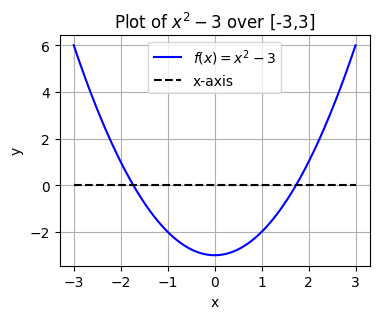

In [27]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-3, 3, 1e-3) # create x from -3 to 3 with dx = 1e-3
y = x ** 2 - 3             # calculate y of each x


plt.figure(figsize=(4, 3)) # customize the figure size in inches (width 4, height 3)

plt.plot(x, y, color='b', label="$f(x) = x^2-3$")                         # plot y
plt.plot([-3, 3], [0, 0], color='k', linestyle='--', label="x-axis") # plot x = 0 to show x-intercept

plt.title("Plot of $x^2-3$ over [-3,3]")
plt.xlabel("x")     # label x-axis
plt.ylabel("y")     # label y-axis
plt.legend()        # show legend
plt.grid()          # show grid
plt.show()          # show figure



##### q.(b)

In [2]:
import numpy as np

'''define bisection method by arguments f(x), initial guess a & b, 
   and tolerance to stop the iteration'''
def bisection(f, a, b, tolerance = 2e-2):

    if f(a) * f(b) > 0: # if (output of) a & b at same side, the root can't be found
        raise Exception("The two points doesn't cross the root") 
    
    mid = (a + b)/2             # middle of [a,b]

    if abs(b - a) < tolerance : # when root is found under tolerance
        return mid
    
    elif f(a) * f(mid) < 0:     # replace 'a' with 'mid', if 'mid' at opposite side of b
        return bisection(f, a, mid, tolerance)
    
    elif f(mid) * f(b) < 0:     # replace 'a' with 'mid', if 'mid' at opposite side of b
        return bisection(f, mid, b, tolerance)
    
def f(x):
    return x ** 2 - 3

b_root = bisection(f, 0, 2)
print(f"root = {b_root}")


root = 1.7265625


### Problem 2

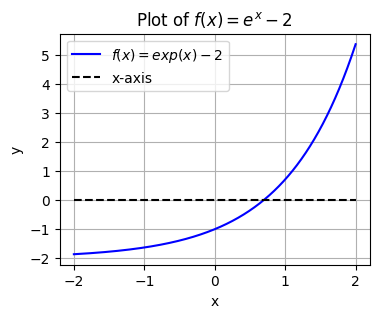

In [38]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-2, 2, 1e-3) # create x from -2 to 2 with dx = 1e-3
y = np.exp(x) - 2          # calculate y of each x


plt.figure(figsize=(4, 3)) # customize the figure size in inches (width 4, height 3)

plt.plot(x, y, color='b', label="$f(x) = exp(x)-2$")                         # plot y
plt.plot([-2, 2], [0, 0], color='k', linestyle='--', label="x-axis") # plot x = 0 to show x-intercept

plt.title("Plot of $f(x)=e^x-2$")
plt.xlabel("x")     # label x-axis
plt.ylabel("y")     # label y-axis
plt.legend()        # show legend
plt.grid()          # show grid
plt.show()          # show figure

In [4]:
import numpy as np

# define newton_raphson with arguments f(x), df(x)/dx, initial guess x, and tolerance (default = 1e-6)
def newton_raphson(f, df, x, tolerance = 1e-6, n=0):
    
    x_new = x - f(x) / df(x)       # for each iteration calculate x_(n+1)
    n = n + 1                      # counter

    if abs(x_new - x) < tolerance: # compare x_n to x_(n+1), if less than tolerance, stops the iteration
        return x_new, n
    
    else:                          # else, continue the iteration
         return newton_raphson(f, df, x_new, tolerance, n)

def f(x):                          # define f(x) = exp(x) - 2
    return np.exp(x) - 2

def df(x):                         # define df(x)/dx = exp(x)
    return np.exp(x)

nr_root, n = newton_raphson(f, df, x=0) # find root using Newton Raphson

print(f"root= {nr_root} at {n}th iteration") # print out result

root= 0.6931471805600254 at 5th iteration


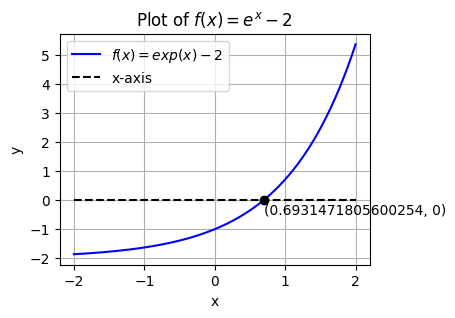

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-2, 2, 1e-3) # create x from -2 to 2 with dx = 1e-3
y = np.exp(x) - 2          # calculate y of each x


plt.figure(figsize=(4, 3)) # customize the figure size in inches (width 4, height 3)

plt.plot(x, y, color='b', label="$f(x) = exp(x)-2$")                 # plot y
plt.plot([-2, 2], [0, 0], color='k', linestyle='--', label="x-axis") # plot x = 0 to show x-intercept
plt.scatter(nr_root, 0, color='k', zorder=2) # plot root and annotate (label) it
plt.annotate(f"({nr_root}, 0)", (nr_root, 0), textcoords="offset points", xytext=(0, -10))

plt.title("Plot of $f(x)=e^x-2$")
plt.xlabel("x")     # label x-axis
plt.ylabel("y")     # label y-axis
plt.legend()        # show legend
plt.grid()          # show grid
plt.show()          # show figure

In [22]:
import numpy as np

def bisection(f, a, b, tolerance = 1e-6, n=0): # f: function | a: start | b: end

    if f(a) * f(b) > 0:
        raise Exception("The two points doesn't cross the root")
    
    mid = (a + b)/2
    n = n + 1

    if abs(b - a) < tolerance :
        return mid, n
    
    elif f(a) * f(mid) < 0:
        return bisection(f, a, mid, tolerance, n)
    
    elif f(mid) * f(b) < 0:
        return bisection(f, mid, b, tolerance, n)

    else:
        raise Exception("something wrong")
    
def f(x):                    # define f(x) = exp(x) - 2
    return np.exp(x) - 2
    
b_root, n = bisection(f, a=0, b=1)
print(f"root= {b_root} at {n}th iteration")

root= 0.6931471824645996 at 21th iteration


##### Secant Method

In [29]:
import numpy as np

# define Secant with arguments f(x), x0, x1, and tolerance (default = 1e-6)
def secant(f, x0, x1, tolerance = 1e-6, n=0):

    x_new = x1 - f(x1) * (x1 - x0)/(f(x1)-f(x0))
    n+=1
    
    if abs(x_new - x1) < tolerance:
        return x_new, n
    else:
         return secant(f, x1, x_new, tolerance, n)

def f(x):
    return np.exp(x) - 2

s_root, n = secant(f, x0 = 0, x1 = 1)
print(f"root = {s_root} at {n}th iteration")

root = 0.6931471805599592 at 6th iteration


In [62]:
2/np.exp(1)

np.float64(0.7357588823428847)

In [63]:
0.735758882-(np.exp(0.735758882)-2)/np.exp(0.735758882)

np.float64(0.6940422999046112)

In [19]:
import numpy as np

def newton_raphson(f, df, x, iterations=3):
    for _ in range(iterations):
        print(x, _)
        x = x - f(x) / df(x)
    return x

def f(x):
    return np.exp(x) - 2

def df(x):
    return np.exp(x)

nr_root = newton_raphson(f, df, x=1)  # start from x=0

print(f"Root after 3 iterations = {nr_root}")


1 0
0.7357588823428847 1
0.6940422999189153 2
Root after 3 iterations = 0.6931475810597714


In [ ]:
x =    0.6931471824645996 * 1e10
true = 0.6931471805599453 * 1e10
absx = abs(true-x)
print(absx * 1e-10)


1.9046543121337893e-09


In [5]:
rel = absx/true
rel

2.7478353307231974e-09